# Linear Regression Handson

<https://colab.research.google.com/drive/1lsgPEJOBx3uLLJMP8OBU9L9QcKXjhpHE?usp=sharing#scrollTo=TQZTTeyKUqw8>

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
dataset = pd.read_csv('insurance_data.csv')
df = dataset.copy()

# LOAD & OVERVIEW 
print(df.shape) 
print(df.dtypes)
print(df.head())
print(df.isnull().sum())
df.info()

(1338, 13)
age                                float64
sex                                    str
bmi                                float64
children                           float64
smoker                                 str
Claim_Amount                       float64
past_consultations                 float64
num_of_steps                       float64
Hospital_expenditure               float64
NUmber_of_past_hospitalizations    float64
Anual_Salary                       float64
region                                 str
charges                            float64
dtype: object
    age   sex    bmi  children smoker  Claim_Amount  past_consultations  \
0  18.0  male  23.21       0.0     no   29087.54313                17.0   
1  18.0  male  30.14       0.0     no   39053.67437                 7.0   
2  18.0  male  33.33       0.0     no   39023.62759                19.0   
3  18.0  male  33.66       0.0     no   28185.39332                11.0   
4  18.0  male  34.10       0.0     no   1

### data set is about the basic parameters of people like bmi, age, smoker non smoker who have applied for insurance, other details to calculate insurance premium


## Predict the final charges for the Insaurance

- So, charges is my Target Column/Output/dependent
- Charges -> Continuous Data
- Regression Problem

### EDA and Data Preprocessing ->
- Null Values
- Duplicates
- Outliers
- Encoding

In [14]:
print(df.isnull().sum())

age                                 9
sex                                 0
bmi                                 3
children                            5
smoker                              0
Claim_Amount                       14
past_consultations                  6
num_of_steps                        3
Hospital_expenditure                4
NUmber_of_past_hospitalizations     2
Anual_Salary                        6
region                              0
charges                             0
dtype: int64


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   str    
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   str    
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   str    
 12  charges                        

### Null Values ->

In [16]:
for i in df.columns:
  if(df[i].dtype != "str"):
    df[i] = df[i].fillna(df[i].median())

In [17]:
df.isnull().sum()

age                                0
sex                                0
bmi                                0
children                           0
smoker                             0
Claim_Amount                       0
past_consultations                 0
num_of_steps                       0
Hospital_expenditure               0
NUmber_of_past_hospitalizations    0
Anual_Salary                       0
region                             0
charges                            0
dtype: int64

### Duplicate ->

In [18]:
df.duplicated().sum()

np.int64(0)

### Outliers ->

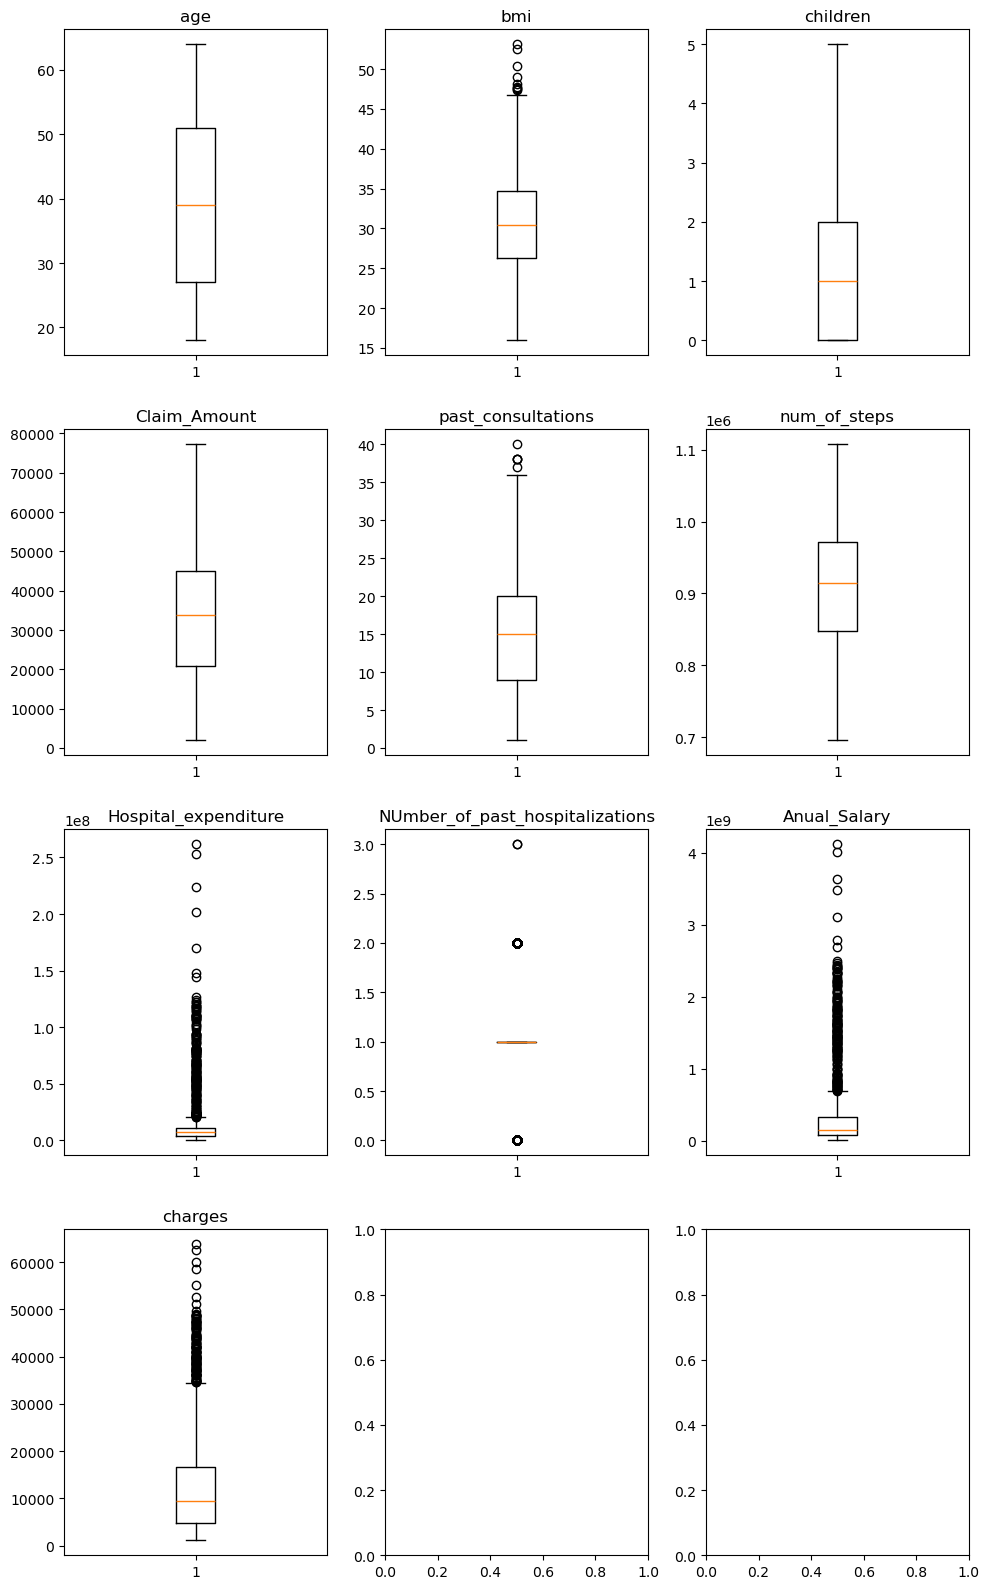

In [29]:
cols = df.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(4, 3, figsize=(10, 16))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [30]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='str')

### Remove the Outliers

In [31]:
outliers = ["bmi", "past_consultations", "Hospital_expenditure", "Anual_Salary"]

In [33]:
for i in outliers:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3-Q1
    LB = Q1-1.5*IQR
    UB = Q3+1.5*IQR
    df = df[(df[i]>=LB) & (df[i]<=UB)]

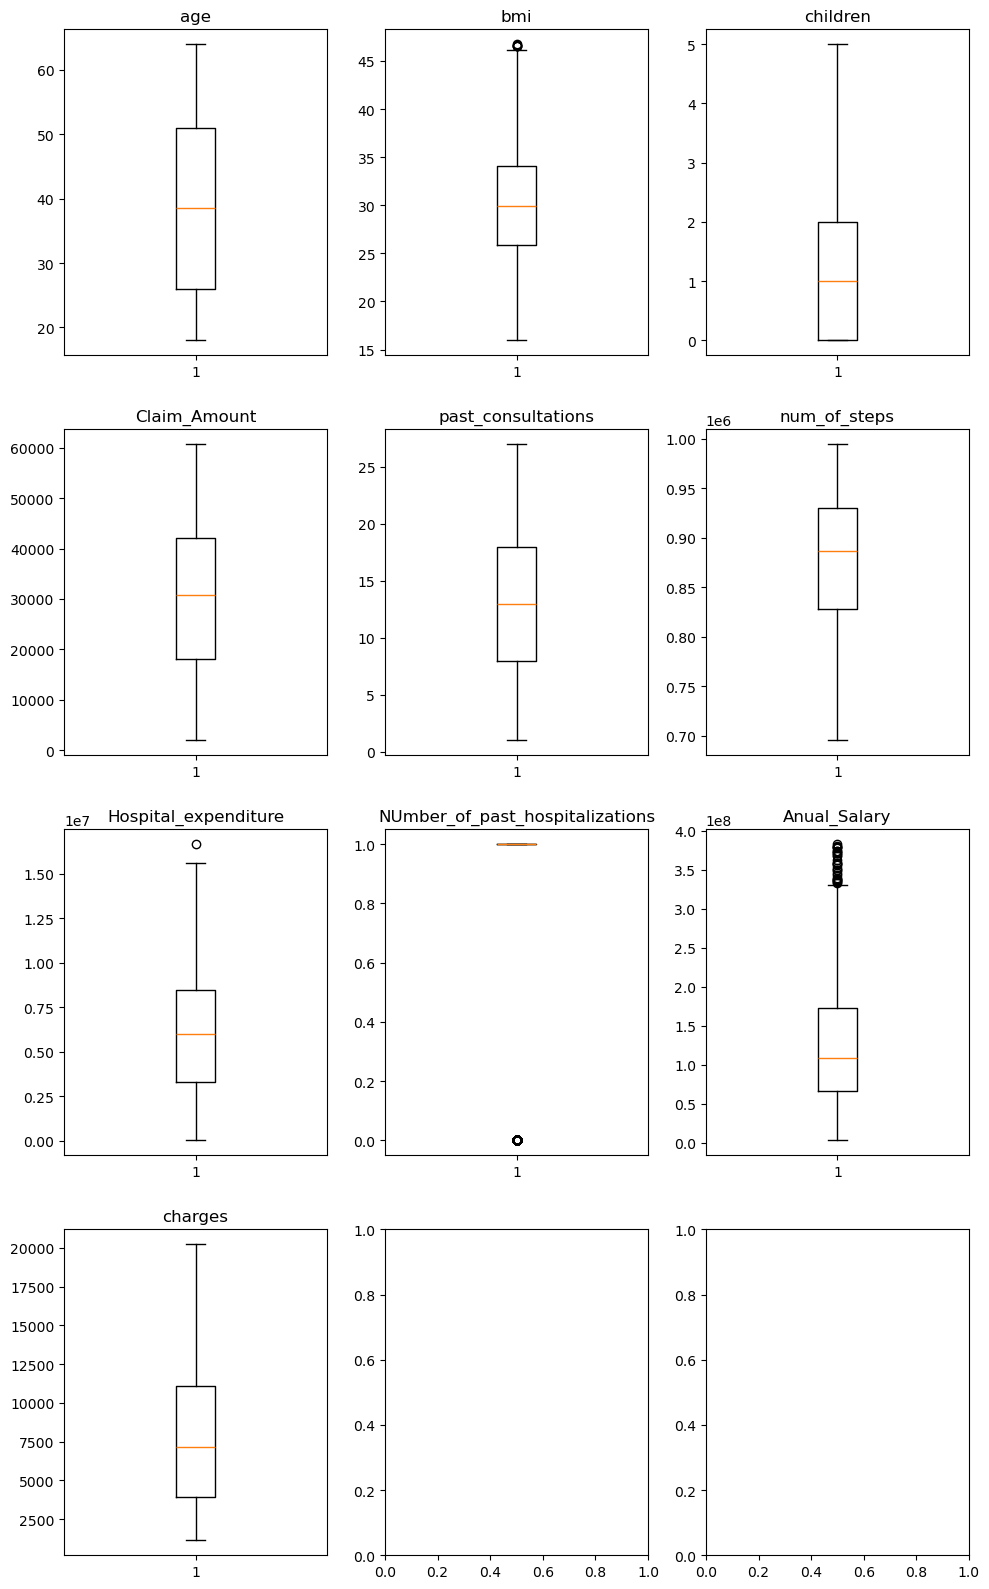

In [34]:
cols = df.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(4, 3, figsize=(10, 16))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### Encoding -> Convert object columns into Numeric

### Label Encoding

In [35]:
from sklearn.preprocessing import LabelEncoder

In [38]:
le = LabelEncoder()
for i in df.columns:
    if(df[i].dtype == "str"):
        df[i] = le.fit_transform(df[i])

In [39]:
df.info()

<class 'pandas.DataFrame'>
Index: 1030 entries, 0 to 1069
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1030 non-null   float64
 1   sex                              1030 non-null   int64  
 2   bmi                              1030 non-null   float64
 3   children                         1030 non-null   float64
 4   smoker                           1030 non-null   int64  
 5   Claim_Amount                     1030 non-null   float64
 6   past_consultations               1030 non-null   float64
 7   num_of_steps                     1030 non-null   float64
 8   Hospital_expenditure             1030 non-null   float64
 9   NUmber_of_past_hospitalizations  1030 non-null   float64
 10  Anual_Salary                     1030 non-null   float64
 11  region                           1030 non-null   int64  
 12  charges                          103

## Build the ML Model ->

- Import Libraries
- Split Data Independent(x) and Dependent(y) Column
- Split the data for Training and Testing
- Train the Model
- Test the Model
- Evaluate the Model

In [ ]:
# Split Data Independent(x) and Dependent(y) Column

# y = mx + c

# x -> All the Data columns rather than the target column (Independent Columns) -> Question

# y -> Only the Target Column (Dependent column) > Answer

In [42]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,1,23.210,0.0,0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,2,1121.87390
1,18.0,1,30.140,0.0,0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,2,1131.50660
2,18.0,1,33.330,0.0,0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,2,1135.94070
3,18.0,1,33.660,0.0,0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,2,1136.39940
4,18.0,1,34.100,0.0,0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,2,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1046,29.0,0,27.940,1.0,1,51168.25474,23.0,993751.0,1.665982e+07,1.0,3.712188e+08,2,19107.77960
1048,31.0,1,25.900,3.0,1,46619.40230,27.0,989387.0,1.361938e+07,1.0,3.812895e+08,3,19199.94400
1050,31.0,1,29.810,0.0,1,24382.58056,21.0,973924.0,1.028991e+07,1.0,3.745310e+08,2,19350.36890
1062,43.0,0,20.045,2.0,1,21596.43846,10.0,994419.0,1.083030e+07,1.0,1.419361e+08,0,19798.05455


In [40]:
x = df.drop(columns="charges")

In [41]:
x

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
0,18.0,1,23.210,0.0,0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,2
1,18.0,1,30.140,0.0,0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,2
2,18.0,1,33.330,0.0,0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,2
3,18.0,1,33.660,0.0,0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,2
4,18.0,1,34.100,0.0,0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1046,29.0,0,27.940,1.0,1,51168.25474,23.0,993751.0,1.665982e+07,1.0,3.712188e+08,2
1048,31.0,1,25.900,3.0,1,46619.40230,27.0,989387.0,1.361938e+07,1.0,3.812895e+08,3
1050,31.0,1,29.810,0.0,1,24382.58056,21.0,973924.0,1.028991e+07,1.0,3.745310e+08,2
1062,43.0,0,20.045,2.0,1,21596.43846,10.0,994419.0,1.083030e+07,1.0,1.419361e+08,0


In [43]:
y = df["charges"]

In [44]:
y

0        1121.87390
1        1131.50660
2        1135.94070
3        1136.39940
4        1137.01100
           ...     
1046    19107.77960
1048    19199.94400
1050    19350.36890
1062    19798.05455
1069    20234.85475
Name: charges, Length: 1030, dtype: float64

In [45]:
df.shape

(1030, 13)

In [46]:
x.shape

(1030, 12)

In [47]:
y.shape

(1030,)

In [48]:
# Split the data for Training and Testing

In [49]:
from sklearn.model_selection import train_test_split

In [50]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [51]:
x_train.shape

(824, 12)

In [52]:
y_train.shape

(824,)

In [53]:
x_test.shape

(206, 12)

In [54]:
y_test.shape

(206,)

In [57]:
# Train the Model

In [55]:
from sklearn.linear_model import LinearRegression

In [56]:
model = LinearRegression()

In [58]:
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [59]:
# Test the Model

In [60]:
y_pred = model.predict(x_test)

In [70]:
y_pred

y_pred_ser = pd.Series(y_pred)
y_pred_ser

0       1533.967880
1       1438.397450
2       2718.140846
3       1909.701733
4      14026.254941
           ...     
201     6291.084217
202     7300.792313
203     3259.718596
204     6602.995568
205     9523.009637
Length: 206, dtype: float64

In [71]:
y_test

32      1629.8335
110     2155.6815
137     2396.0959
89      1981.5819
924    13430.2650
          ...    
484     6746.7425
547     7537.1639
111     2156.7518
516     7162.0122
605     8515.7587
Name: charges, Length: 206, dtype: float64

In [62]:
# Evaluate the Model

In [63]:
from sklearn.metrics import *

In [64]:
r2_score(y_test, y_pred)

0.9632050978229458

In [65]:
mean_absolute_error(y_test, y_pred)

624.1177019069974

In [66]:
mean_squared_error(y_test, y_pred)

741176.3450151228

In [67]:
root_mean_squared_error(y_test, y_pred)

860.9159918453848

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

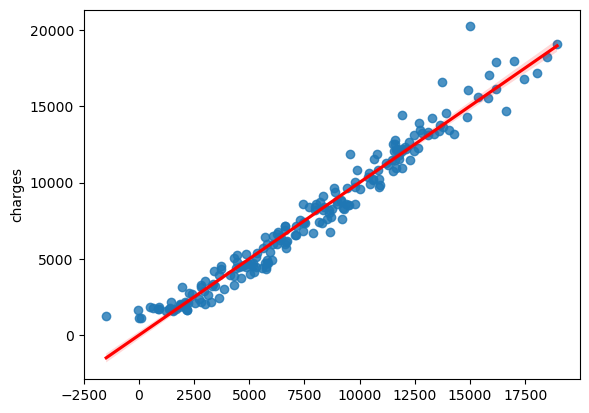

In [69]:
sns.regplot(x=y_pred, y=y_test, line_kws={"color" : "red"})
plt.show()